# Malaria PfPR covariate model selection
### Methods report

We select the covariate specification for the malaria PfPR shape-constrained additive model (`scam`, logit-PfPR response) by (1) enumerating a neighborhood of candidate specifications, (2) scoring each on **temporal out-of-sample (OOS)** skill across a bank of train/test windows using three PfPR-space metrics, (3) removing redundant metrics with a Kendall-τ pruning step, and (4) aggregating the surviving metrics into a single ranking with three consensus methods (Borda count, TOPSIS, pairwise dominance).

All candidate models share an additive country fixed effect (`A0_af`); the fixed effect is taken as given here and its role is documented separately. This report is reproducible from the run's stat-complete artifact, `selection_summary.parquet`.

**Headline result.** Under `oos_pfpr_r` (correlation) alone the top-ranked specification (spec 47) is **model 13 plus a monotone-decreasing urban smooth**; adding the calibration metrics (`oos_pfpr_rmse`, `oos_pfpr_mae`) drops that extra term and selects **model 13**. Correlation rewards the added flexibility; the level-based error metrics do not. Suitability and temperature enter linearly in both — their functional form is a separate, within-noise axis (Section 6).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from idd_forecast_mbp.select.model_selection import (
    kendall_tau_heatmap, prune_redundant_metrics,
    borda_rank, topsis_rank, pairwise_dominance_summary,
)
pd.set_option('display.width', 200); pd.set_option('display.max_colwidth', 200)

RUN_DIR = Path('/mnt/team/idd/pub/forecast-mbp/03-modeling_data/malaria/scam_prelim/lsae_1285/20260720_efs')
summary = pd.read_parquet(RUN_DIR / 'selection_summary.parquet')
spec    = pd.read_parquet(RUN_DIR / 'spec_table.parquet').set_index('spec_index')

# the three PfPR-space OOS metrics and their ranking direction
OOS_METRICS = {'oos_pfpr_r': 'higher', 'oos_pfpr_rmse': 'lower', 'oos_pfpr_mae': 'lower'}
windows = sorted({c.split('__')[0] for c in summary.columns if '__oos_pfpr_r' in c})
r_cols   = [f'{w}__oos_pfpr_r' for w in windows]
all_cols = [f'{w}__{m}' for w in windows for m in OOS_METRICS]

sc = summary.dropna(subset=r_cols).copy()
sc['task_id'] = sc['spec_index'].astype(str)   # id column the ranking helpers display
print(f'{len(sc)} FE specifications  |  {len(windows)} temporal windows  |  '
      f'{len(all_cols)} (metric x window) scores')

1620 FE specifications  |  10 temporal windows  |  30 (metric x window) scores


In [2]:
def direction(cols):
    return {c: OOS_METRICS[c.rsplit('__', 1)[1]] for c in cols}

def rank_specs(cols, threshold, rank_method='consensus_rank'):
    """Full pipeline for one (metric-set, tau-threshold): prune -> Borda/TOPSIS/dominance
    -> consensus. Returns (n_surviving_metrics, ranked_df sorted by consensus_rank)."""
    m = direction(cols)
    tau = kendall_tau_heatmap(sc, m, plot=False)
    m_pruned, _ = prune_redundant_metrics(tau, m, threshold=threshold, verbose=False)
    b, _ = borda_rank(sc, m_pruned, plot=False)
    t, _ = topsis_rank(sc, m_pruned, verbose=False)
    d = pairwise_dominance_summary(sc, m_pruned, plot=False, verbose=False)
    out = (sc[['spec_index', 'n_smooths']]
           .merge(b[['spec_index', 'borda_rank']], on='spec_index')
           .merge(t[['spec_index', 'topsis_rank']], on='spec_index')
           .merge(d[['spec_index', 'dominance_rank']], on='spec_index'))
    out['consensus_rank'] = out[['borda_rank', 'topsis_rank', 'dominance_rank']].mean(axis=1)
    return len(m_pruned), out.sort_values(rank_method).reset_index(drop=True)

## 1. The model space (enumeration)

Each candidate is a `scam` on `logit_malaria_pfpr`. The neighborhood is the cross-product of per-covariate choices, subject to two structural rules, giving **459 specifications**.

**Always in every model** (the backbone):

| term | form |
|---|---|
| `A0_af` | additive country fixed effect |

**Optional covariates** (each independently in-or-out; when in, one functional form):

| covariate | forms considered |
|---|---|
| `mal_DAH_total_per_capita` | monotone-decreasing smooth `s(·, k=4, bs="mpd")` |
| `gdppc_mean` | monotone-decreasing smooth `s(·, k=4, bs="mpd")` |
| suitability | `logit_malaria_suitability` (linear)  **or**  `malaria_suit` monotone-increasing smooth `s(·,k=6,bs="mpi")` |
| temperature | `mean_temperature` or `mean_low_temperature`, each as linear / unconstrained smooth `s(·,k=4)` / monotone-increasing `mpi` |
| urban | linear **or** monotone-decreasing smooth `s(·,k=4,bs="mpd")` |
| precipitation | linear **or** monotone-increasing smooth `s(·,k=4,bs="mpi")` |
| humidity | `logit_relative_humidity` (linear) **or** `relative_humidity` monotone-increasing `s(·,k=6,bs="mpi")` |

**Structural rules.** (a) A specification is excluded if suitability is present *and* a temperature term enters as a monotone-increasing smooth — the suitability term absorbs the temperature signal, collapsing the constrained temperature smooth to zero effective degrees of freedom. (b) Total number of smooth terms ≤ 7. The cell below reports the resulting size and complexity distribution.

In [3]:
print(f'specifications enumerated: {len(spec)}')
print('\nn_smooths distribution (smooth terms per spec):')
print(spec['n_smooths'].value_counts().sort_index().rename('n_specs').to_string())

specifications enumerated: 1620

n_smooths distribution (smooth terms per spec):
n_smooths
0     48
1    224
2    440
3    472
4    299
5    112
6     23
7      2


## 2. Out-of-sample design (temporal windows)

Because the intended use is forward extrapolation, models are scored on **temporal** hold-out, not interpolation: each window trains on `[train_lo, train_hi]` and predicts a disjoint, later `[test_lo, test_hi]`. Windows vary two axes — the **gap** between the end of training and the start of testing (1 / 3 / 7 / 10 years) and the **test era** (pre-2020, full, or recent) — with training starting at 2000 and a minimum of five training years. This yields the **10 windows** below (the shorter-training combinations are dropped by the 5-year floor). The gap axis probes how skill decays as the forecast reaches further past the last observed year.

In [4]:
# window definitions are recorded per-window in the artifact (cv_* bounds)
wrows = []
for w in windows:
    def g(metric):
        col = f'{w}__{metric}'
        return summary[col].dropna().iloc[0] if col in summary else np.nan
    wrows.append({'window': w,
                  'train_lo': int(g('cv_train_lo')), 'train_hi': int(g('cv_train_hi')),
                  'test_lo': int(g('cv_test_lo')),   'test_hi': int(g('cv_test_hi')),
                  'gap_yrs': int(g('cv_test_lo') - g('cv_train_hi'))})
pd.DataFrame(wrows).sort_values(['gap_yrs', 'test_lo']).reset_index(drop=True)

,window,train_lo,train_hi,test_lo,test_hi,gap_yrs
0,narrow_full,2000,2012,2013,2023,1
1,narrow_preC,2000,2012,2013,2019,1
2,narrow_recent,2000,2018,2019,2023,1
3,wide_full,2000,2010,2013,2023,3
4,wide_preC,2000,2010,2013,2019,3
5,wide_recent,2000,2016,2019,2023,3
6,vwide_full,2000,2006,2013,2023,7
7,vwide_preC,2000,2006,2013,2019,7
8,vwide_recent,2000,2012,2019,2023,7
9,exwide_recent,2000,2009,2019,2023,10


## 3. Performance metrics

For each spec × window we compute three **PfPR-space** (natural-scale, not logit) out-of-sample metrics on the held-out test years:

| metric | direction | captures |
|---|---|---|
| `oos_pfpr_r` | higher better | rank/shape agreement (Pearson correlation of predicted vs observed PfPR) |
| `oos_pfpr_rmse` | lower better | calibration, penalising large errors |
| `oos_pfpr_mae` | lower better | calibration, typical error magnitude |

Correlation alone rewards getting the *ordering* right; the two error metrics reward getting the *level* right. As Section 5 shows, that distinction is what determines the selected model. With 10 windows this is 30 (metric × window) scores per specification.

## 4. Metric redundancy reduction (Kendall-τ)

The 30 scores are highly redundant — windows that overlap (e.g. the several recent-era windows) and the three metrics *within* a window tend to rank the specifications the same way. Feeding all 30 into the aggregation would let a correlated block vote many times. We therefore compute the pairwise **Kendall-τ** between the per-score *rankings* and iteratively drop the more-redundant member of any pair with |τ| ≥ threshold, keeping one representative per correlated cluster.

The `threshold` is the knob for “how similar is too similar.” We sweep it 0.5–0.9. The table below shows how many of the 30 scores survive at each threshold; the heatmap shows the τ structure among survivors at 0.7 (our primary setting).

In [5]:
sweep = []
for thr in [0.5, 0.6, 0.7, 0.8, 0.9]:
    n_surv, ranked = rank_specs(all_cols, thr)
    top = ranked.iloc[0]
    sweep.append({'tau_threshold': thr, 'metrics_surviving': n_surv,
                  'consensus_winner': int(top['spec_index']),
                  'winner_n_smooths': int(top['n_smooths'])})
sweep_df = pd.DataFrame(sweep)
print('metric survivors and consensus winner across the tau sweep:')
print(sweep_df.to_string(index=False))


=== Metric Agreement Analysis ===
Average pairwise Kendall tau: 0.583
Pairs with negative correlation: 18
Metrics largely agree. Flat top tier likely reflects genuine equivalence.

=== Metric Agreement Analysis ===
Average pairwise Kendall tau: 0.583
Pairs with negative correlation: 18
Metrics largely agree. Flat top tier likely reflects genuine equivalence.

=== Metric Agreement Analysis ===
Average pairwise Kendall tau: 0.583
Pairs with negative correlation: 18
Metrics largely agree. Flat top tier likely reflects genuine equivalence.

=== Metric Agreement Analysis ===
Average pairwise Kendall tau: 0.583
Pairs with negative correlation: 18
Metrics largely agree. Flat top tier likely reflects genuine equivalence.

=== Metric Agreement Analysis ===
Average pairwise Kendall tau: 0.583
Pairs with negative correlation: 18
Metrics largely agree. Flat top tier likely reflects genuine equivalence.
metric survivors and consensus winner across the tau sweep:
 tau_threshold  metrics_surviving  


=== Metric Agreement Analysis ===
Average pairwise Kendall tau: 0.583
Pairs with negative correlation: 18
Metrics largely agree. Flat top tier likely reflects genuine equivalence.


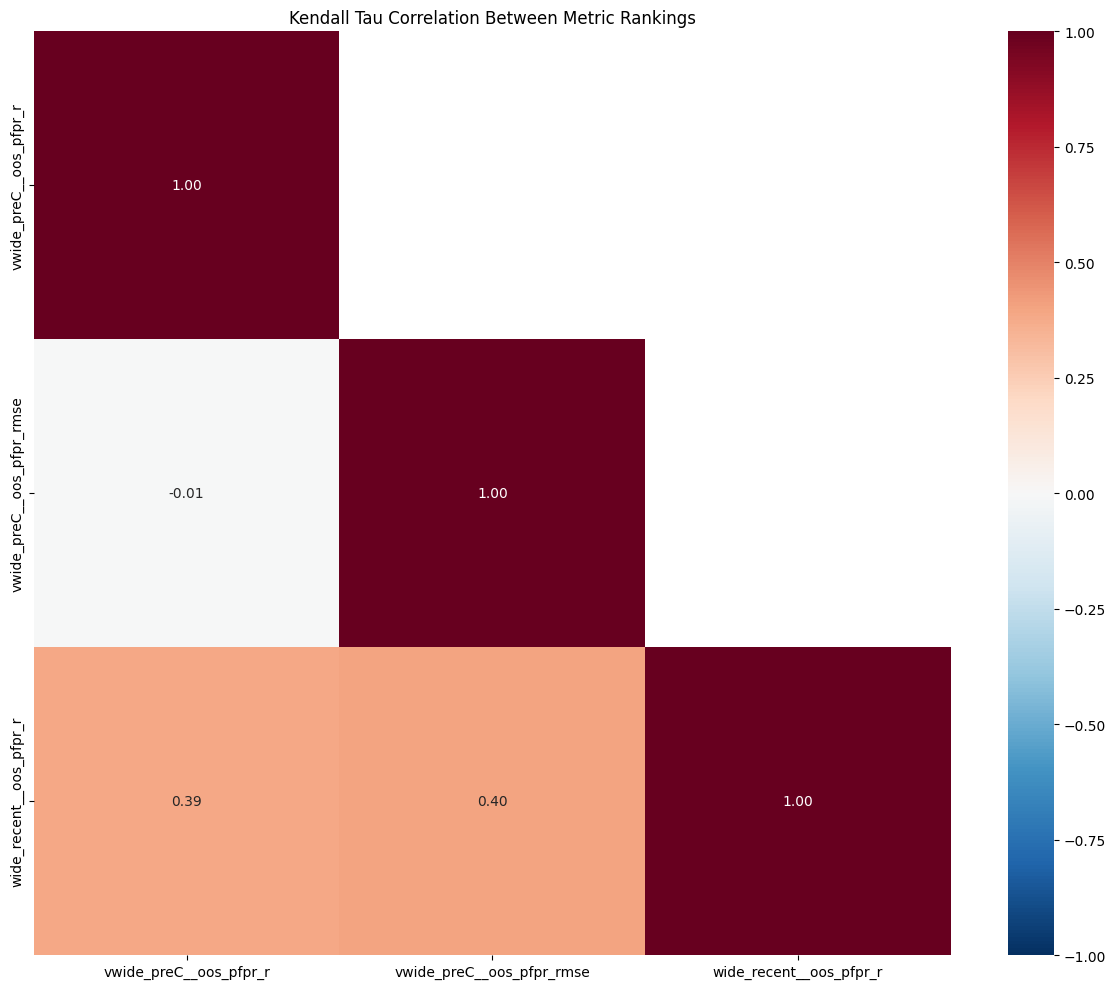


=== Metric Agreement Analysis ===
Average pairwise Kendall tau: 0.260
Pairs with negative correlation: 1
Moderate agreement. Some trade-offs between metrics.


In [7]:
# tau heatmap among the survivors at the primary threshold (0.7)
m = direction(all_cols)
tau0 = kendall_tau_heatmap(sc, m, plot=False)
m07, _ = prune_redundant_metrics(tau0, m, threshold=0.7, verbose=False)
_ = kendall_tau_heatmap(sc, m07, plot=True)

## 5. Consensus ranking — and why the metric set decides the winner

On the pruned metric set we aggregate with three methods and average their ranks into a `consensus_rank`:
- **Borda count** — sum of per-metric ranks (lower = better on more metrics);
- **TOPSIS** — distance to the ideal/anti-ideal point across metrics;
- **pairwise dominance** — how many other specs a spec beats on all metrics.

The pivotal finding: **the choice of metric set changes the winner.** With correlation alone (`oos_pfpr_r`), the top-ranked specification is **spec 47** — model 13 plus a monotone-decreasing urban smooth `s(urban, bs="mpd")`. Adding the two calibration metrics (`oos_pfpr_rmse`, `oos_pfpr_mae`) — which reward getting the PfPR *level* right, not just its ordering — drops that extra term and moves the consensus winner to the simpler **model 13**. Suitability and temperature enter linearly in both; their functional form is a separate, within-noise axis explored by 13's neighbours (Section 6). The two cells below show the flip, then the full multi-metric top tier.

In [10]:
# single-metric (correlation only) vs full three-metric set, both at tau=0.7
_, rank_r    = rank_specs(r_cols,   0.7, rank_method='borda_rank')
_, rank_all  = rank_specs(all_cols, 0.7, rank_method='borda_rank')
flip = pd.DataFrame({
    'metric_set':      ['oos_pfpr_r only', 'r + rmse + mae'],
    'consensus_winner':[int(rank_r.iloc[0]['spec_index']), int(rank_all.iloc[0]['spec_index'])],
    'winner_n_smooths':[int(rank_r.iloc[0]['n_smooths']),  int(rank_all.iloc[0]['n_smooths'])],
})
print(flip.to_string(index=False))
print('\nformula of each winner:')
for sid in flip['consensus_winner']:
    print(f'  spec {sid}: {spec.loc[sid, "formula_text"]}')


=== Metric Agreement Analysis ===
Average pairwise Kendall tau: 0.717
Pairs with negative correlation: 0
Metrics largely agree. Flat top tier likely reflects genuine equivalence.

=== Metric Agreement Analysis ===
Average pairwise Kendall tau: 0.583
Pairs with negative correlation: 18
Metrics largely agree. Flat top tier likely reflects genuine equivalence.
     metric_set  consensus_winner  winner_n_smooths
oos_pfpr_r only               167                 2
 r + rmse + mae               180                 4

formula of each winner:
  spec 167: logit_malaria_pfpr ~ s(gdppc_mean, k = 4, bs = "mpd") + logit_malaria_suitability + mean_low_temperature + s(weighted_1km_urban_threshold_300.0_simple_mean, k = 4, bs = "mpd") + A0_af
  spec 180: logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = "mpd") + s(gdppc_mean, k = 4, bs = "mpd") + logit_malaria_suitability + s(mean_low_temperature, k = 4) + s(weighted_1km_urban_threshold_300.0_simple_mean, k = 4, bs = "mpd") + A0_af


In [11]:
# full three-metric consensus top tier (tau = 0.7)
rank_all.head(10).round(2)

,spec_index,n_smooths,borda_rank,topsis_rank,dominance_rank,consensus_rank
0,180,4,1.0,2.0,6.5,3.17
1,168,3,2.5,1.0,4.5,2.67
2,60,3,2.5,4.0,1.0,2.50
3,48,2,4.0,3.0,2.0,3.00
4,12,2,5.0,5.0,3.0,4.33
5,120,3,6.0,7.0,8.0,7.00
6,108,2,7.0,6.0,6.5,6.50
7,132,3,8.0,8.0,10.0,8.67
8,72,2,9.0,9.0,11.0,9.67
9,164,4,10.0,10.0,12.5,10.83


## 6. Selected model — model 13

Model 13 is the multi-metric consensus winner (Borda 1, TOPSIS 1, pairwise-dominance 2) and is robust: it is the top-ranked model across the τ sweep (Section 4). Its immediate neighbours — specs **12 / 15 / 16** — are the same backbone with suitability and/or temperature entering as smooths rather than linearly; they are statistically within noise, so **13 is chosen as the most parsimonious member of the tied top cluster** (only the two forced backbone smooths; suitability and temperature linear). The cells below give its formula, place it against that top cluster, and report its per-window OOS performance.

In [14]:
model_set = [168, 180, 60, 48, 12, 120]
print('Model 168:')
print(' ', spec.loc[168, 'formula_text'])
print(f'  smooth terms: {int(spec.loc[168, "n_smooths"])}')

print('\nTop cluster (the suitability x temperature form 2x2 on the shared backbone):')
cluster = rank_all[rank_all['spec_index'].isin(model_set)].copy()
print(cluster[['spec_index', 'n_smooths', 'borda_rank', 'topsis_rank',
               'dominance_rank', 'consensus_rank']].round(2).to_string(index=False))
for sid in model_set:
    print(f'  spec {sid}: {spec.loc[sid, "formula_text"]}')

Model 168:
  logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = "mpd") + s(gdppc_mean, k = 4, bs = "mpd") + logit_malaria_suitability + mean_low_temperature + s(weighted_1km_urban_threshold_300.0_simple_mean, k = 4, bs = "mpd") + A0_af
  smooth terms: 3

Top cluster (the suitability x temperature form 2x2 on the shared backbone):
 spec_index  n_smooths  borda_rank  topsis_rank  dominance_rank  consensus_rank
        180          4         1.0          2.0             6.5            3.17
        168          3         2.5          1.0             4.5            2.67
         60          3         2.5          4.0             1.0            2.50
         48          2         4.0          3.0             2.0            3.00
         12          2         5.0          5.0             3.0            4.33
        120          3         6.0          7.0             8.0            7.00
  spec 168: logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = "mpd") + s(gdppc_mean, k 

In [16]:
row = summary[summary['spec_index'] == 180].iloc[0]
perwin = pd.DataFrame({
    'window':    windows,
    'oos_pfpr_r':    [row[f'{w}__oos_pfpr_r']    for w in windows],
    'oos_pfpr_rmse': [row[f'{w}__oos_pfpr_rmse'] for w in windows],
    'oos_pfpr_mae':  [row[f'{w}__oos_pfpr_mae']  for w in windows],
}).round(4)
perwin

,window,oos_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae
0,exwide_recent,0.8289,0.1006,0.0654
1,narrow_full,0.8019,0.1053,0.0652
2,narrow_preC,0.7964,0.1070,0.0648
3,narrow_recent,0.8291,0.0875,0.0553
4,vwide_full,0.7937,0.0999,0.0626
5,vwide_preC,0.7809,0.1043,0.0638
6,vwide_recent,0.8189,0.1007,0.0643
7,wide_full,0.8010,0.1093,0.0682
8,wide_preC,0.7918,0.1113,0.0681
9,wide_recent,0.8219,0.0919,0.0582


In [ ]:
row = summary[summary['spec_index'] == 12].iloc[0]
perwin = pd.DataFrame({
    'window':    windows,
    'oos_pfpr_r':    [row[f'{w}__oos_pfpr_r']    for w in windows],
    'oos_pfpr_rmse': [row[f'{w}__oos_pfpr_rmse'] for w in windows],
    'oos_pfpr_mae':  [row[f'{w}__oos_pfpr_mae']  for w in windows],
}).round(4)
perwin

,window,oos_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae
0,exwide_recent,0.8294,0.1015,0.0664
1,narrow_full,0.8010,0.1056,0.0655
2,narrow_preC,0.7948,0.1070,0.0649
3,narrow_recent,0.8300,0.0879,0.0559
4,vwide_full,0.7931,0.0992,0.0619
5,vwide_preC,0.7798,0.1036,0.0631
6,vwide_recent,0.8193,0.1016,0.0653
7,wide_full,0.8002,0.1090,0.0682
8,wide_preC,0.7906,0.1107,0.0676
9,wide_recent,0.8229,0.0924,0.0589
